In [2]:
# import mitsuba
import math

from scipy import constants as const

# import drjit
import drjit as dr
import matplotlib.pyplot as plt
import numpy as np

import mitsuba as mi

# colocar el valor de spectral
mi.set_variant("cuda_ad_spectral")

from mitsuba import ScalarTransform4f as T


In [3]:
def load_sensor_spectral(
    r: float,
    phi: float,
    theta: float,
    wave_lengths: np.ndarray,
    sigma: float,
    k: float = 3,
    n_wavelents: int = 5,
):
    """
    Load a sensor with Gaussian response.

    Args:
        r (float): Radius of the sensor.
        phi (float): Azimuthal angle in degrees.
        theta (float): Polar angle in degrees.
        wave_lengths (np.ndarray): Wavelengths for the Gaussian response.
        sigma (float): Standard deviation of the Gaussian.
        k (float, optional): Number of standard deviations. Default is 3.
        n_wavelents (int, optional): Number of wavelengths. Default is 5.
    """
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    film_dic = {
        "type": "specfilm",
        "width": 256,
        "height": 256,
        "rfilter": {
            "type": "gaussian",
        },
    }

    for i, wave_length in enumerate(wave_lengths):
        if i == len(wave_lengths) - 1:
            wmin = int(wave_length-1)
            wmax = int(wave_length)
        else:
            wmin = int(wave_length)
            wmax = int(wave_length + 1)

        values = "1.0, 1.0"

        film_dic[f"band_{wave_length}"] = {
            "type": "regular",
            "wavelength_min": wmin,
            "wavelength_max": wmax,
            "values": values,
        }

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "multijitter", "sample_count": 16384, "seed": 42},
        "film": film_dic,
    }

In [4]:
def load_sensor_rgb(r, phi, theta):
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 16},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {
                "type": "tent",
            },
            "pixel_format": "rgb",
        },
    }


In [5]:
def load_sensor_depth(r, phi, theta):
    z = r * np.sin(math.radians(theta))
    y = r * np.cos(math.radians(theta)) * np.sin(math.radians(phi))
    x = r * np.cos(math.radians(theta)) * np.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 1},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {"type": "box"},
            "pixel_format": "luminance",
            "component_format": "float32",
        },
    }


In [6]:
wave_lengths = np.linspace(8000, 14000, 49).astype(int)

spp = 1024 * 16

sigma = 10
r = 35
phi = 0
theta = 0
k = 3
n = 15

sensor_espectral = mi.load_dict(
    load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
)

In [7]:
def blackbody_radiance_nm(wavelengths_nm, temperature):
    """
    Compute spectral radiance B(λ, T) of a black body
    using scipy constants.

    Args:
        wavelengths_nm: array-like of wavelengths in nanometers (nm).
        temperature:    temperature in Kelvin (K).

    Returns:
        numpy array of spectral radiance in  μW/cm²/sr/μm (microflicks)
    """
    # Convert wavelengths to meters
    wavelengths_m = np.array(wavelengths_nm, dtype=float) * 1e-9

    # Planck's law for spectral radiance: from W/m²/sr/m
    exponent = (const.h * const.c) / (wavelengths_m * const.k * temperature)
    radiance = (2 * const.h * const.c**2) / (wavelengths_m**5) / (np.exp(exponent) - 1)

    # Convert radiance from W/m²/sr/m to μW/cm²/sr/μm
    radiance = radiance * 1e-4

    return radiance

In [8]:
dataBaseName = np.load("../assets/reference_data/matName_FullDatabase.npy", allow_pickle=True).item()[
    "matName"
]
dataBaseName = dataBaseName.squeeze()
dataBaseName = np.hstack(dataBaseName)  # lista de nombres de los materiales

dataBaseLib = np.load("../assets/reference_data/matLib_FullDatabase.npy", allow_pickle=True).item()[
    "matLib"
]
dataBaseLib = dataBaseLib[::-1, :]  # Reverso el orden de la base de datos

# vamos a asumir que las 49 firmas espectrales coinciden con las 49 longitudes de onda de la escena

print(dataBaseName.shape)
print(dataBaseLib.shape)
print(dataBaseName)


(30,)
(49, 30)
['sky' 'asphalt' 'tilePavement' 'cinderblock' 'brick' 'wall' 'marble'
 'stone' 'soil' 'al' 'weatheredMetal' 'brass' 'al2o3' 'oxidizedSteel'
 'iron' 'carpaint' 'plasticPaint' 'yellowSpray' 'carwindow' 'crystalGlass'
 'tire' 'cloths' 'card' 'tree' 'grass' 'flower' 'water' 'human' 'bark'
 'concrete']


In [9]:
def detect_header_lines(file_path: str) -> int:
    skip_rows = 0
    
    with open(file_path, 'r') as file:
        for line_num, line in enumerate(file):
            line = line.strip()
            
            # Saltar líneas vacías
            if not line:
                skip_rows += 1
                continue
            
            # Intentar dividir la línea en columnas
            parts = line.split()
            
            # Verificar si la línea contiene al menos 2 números
            if len(parts) >= 2:
                try:
                    # Intentar convertir las primeras dos columnas a float
                    float(parts[0])
                    float(parts[1])
                    return skip_rows
                except ValueError:
                    # Esta línea no contiene números válidos, es parte del encabezado
                    skip_rows += 1
                    continue
            else:
                # Línea con menos de 2 columnas, es parte del encabezado
                skip_rows += 1
    
    raise ValueError("No se encontraron datos numéricos válidos en el archivo")

def extract_spectral_values(wavelengths: np.ndarray, file_path: str) -> np.ndarray:

    skips = detect_header_lines(file_path)

    data = np.loadtxt(file_path, skiprows=skips)

    waves = data[:, 0]*1000 # Convertir de micrómetros a nanómetros
    reflectance = data[:, 1]/100 # Convertir porcentaje a fracción
    emissivity = 1 - reflectance

    emissivity_values = []

    for wavelength in wavelengths:
        idx = np.argmin(np.abs(waves - wavelength))
        emissivity_values.append(emissivity[idx])

    emissivity_values = np.array(emissivity_values)

    return emissivity_values

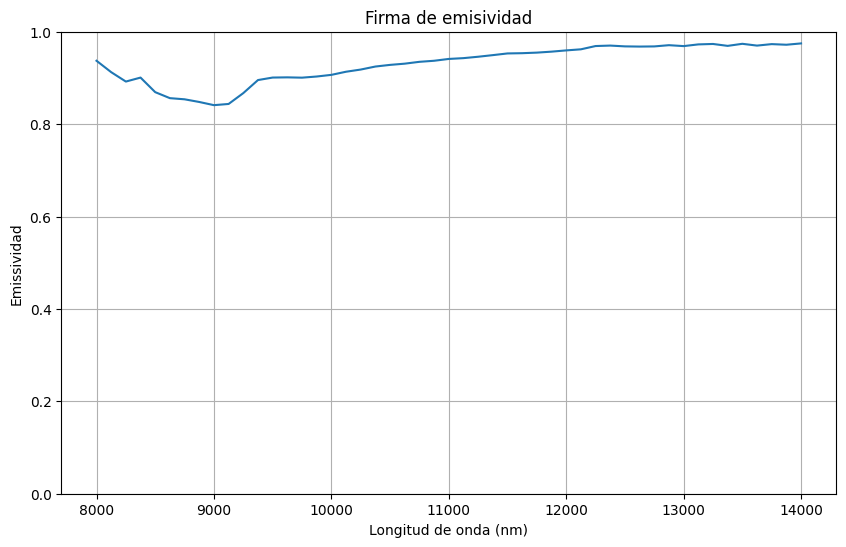

In [10]:
# Ejemplo de uso con el archivo de firma espectral
firma_path = r"C:\Users\mgefr\Documents\1UIS\proyecto-grado\assets\materials\default.txt"

firma_test = extract_spectral_values(wave_lengths, firma_path)

plt.figure(figsize=(10, 6))
plt.plot(wave_lengths, firma_test)
plt.ylim(0,1)
plt.title("Firma de emisividad")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Emissividad")
plt.grid(True)
plt.show()


(49,)


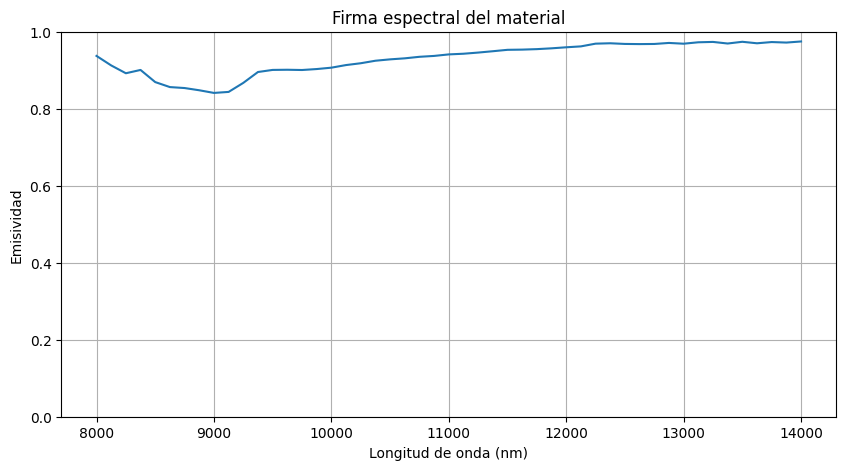

In [11]:
material = "stone"  # escoge el material que quieres
indice_material = np.where(dataBaseName == material)[0][
    0
]  # busca el indice del material en la base de datos

firma = dataBaseLib[:, indice_material]  # firma espectral del material

firma = extract_spectral_values(wave_lengths, firma_path)

# firma[24] = 0
# firma[25] = 0.5
# firma[26] = 1.0
# firma[27] = 0
# firma[28] = 0.5
# firma[29] = 1.0

print(firma.shape)

# plot
plt.figure(figsize=(10, 5))
plt.plot(wave_lengths, firma)
plt.title("Firma espectral del material")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Emisividad")
plt.ylim(0, 1)
plt.grid()
plt.show()

In [12]:
def make_emissivity_3parts(
    wavelengths_um: np.ndarray,
    M_spikes: int = 6,              # número de picos aleatorios en la 3ra parte
    sigma_gauss_part1: float = 0.18,# sigma (en [0,1]) para la gaussiana del 1er tercio
    spike_amp_range=(0.4, 1.0),     # amplitud de picos aleatorios en 3er tercio
    spike_sigma_range_frac=(0.02, 0.10), # ancho relativo de picos (fracción del 3er tercio)
    seed: int | None = 42           # semilla para reproducibilidad
):
    """
    Genera ε(λ) en tres partes:
      1) Gaussiana (0→1→0) en el primer tercio.
      2) Rampa lineal 0→1 en el segundo tercio.
      3) Región con picos aleatorios 0..1 (suma de gaussianas) en el último tercio.

    Parameters
    ----------
    wavelengths_um : array (Nλ,)
    M_spikes : int
        Número de picos aleatorios en la 3ra parte.
    sigma_gauss_part1 : float
        Desviación típica (en coordenadas normalizadas [0,1]) de la gaussiana del 1er tercio.
    spike_amp_range : tuple(float, float)
        Rango de amplitudes para los picos aleatorios (0..1).
    spike_sigma_range_frac : tuple(float, float)
        Rango de sigmas como fracción del tamaño del 3er tercio (en unidades de índice).
    seed : int | None
        Semilla para RNG.

    Returns
    -------
    eps : np.ndarray (Nλ,) con valores en [0,1]
    parts_idx : dict con slices de cada parte {'p1': slice, 'p2': slice, 'p3': slice}
    """
    wl = np.asarray(wavelengths_um)
    N = wl.size
    assert N >= 9, "Se recomiendan al menos 9 bandas para dividir en 3 partes."

    # Particiones (enteros)
    n1 = N // 3
    n2 = 2 * N // 3
    s1 = slice(0, n1)
    s2 = slice(n1, n2)
    s3 = slice(n2, N)

    eps = np.zeros(N, dtype=float)

    # --- Parte 1: gaussiana normalizada en [0,1] ---
    x1 = np.linspace(0, 1, n1, endpoint=True)
    mu1 = 0.5
    sig1 = sigma_gauss_part1
    p1 = np.exp(-0.5 * ((x1 - mu1) / sig1) ** 2)  # ya queda 0..1 (pico=1)
    eps[s1] = p1

    # --- Parte 2: rampa 0 -> 1 ---
    if n2 - n1 > 0:
        eps[s2] = np.linspace(0, 1, n2 - n1, endpoint=True)

    # --- Parte 3: picos aleatorios 0..1 ---
    rng = np.random.default_rng(seed)
    n3 = N - n2
    x3 = np.arange(n3, dtype=float)

    # Base (opcional: ruido leve para “textura”)
    p3 = np.zeros(n3, dtype=float)

    # Generar picos gaussianos
    # sigma en índices del 3er tercio (no en µm); control con fracción
    sig_min = max(1.0, spike_sigma_range_frac[0] * n3)
    sig_max = max(sig_min, spike_sigma_range_frac[1] * n3)

    for _ in range(M_spikes):
        c = rng.uniform(0, n3 - 1)  # centro (en índice fraccional)
        a = rng.uniform(*spike_amp_range)
        s = rng.uniform(sig_min, sig_max)
        p3 += a * np.exp(-0.5 * ((x3 - c) / s) ** 2)

    # Normalizar p3 a [0,1] si supera 1
    if p3.max() > 0:
        p3 = p3 / p3.max()

    eps[s3] = p3

    # Clip final a [0,1]
    eps = np.clip(eps, 0.0, 1.0)

    parts_idx = {"p1": s1, "p2": s2, "p3": s3}
    return eps, parts_idx


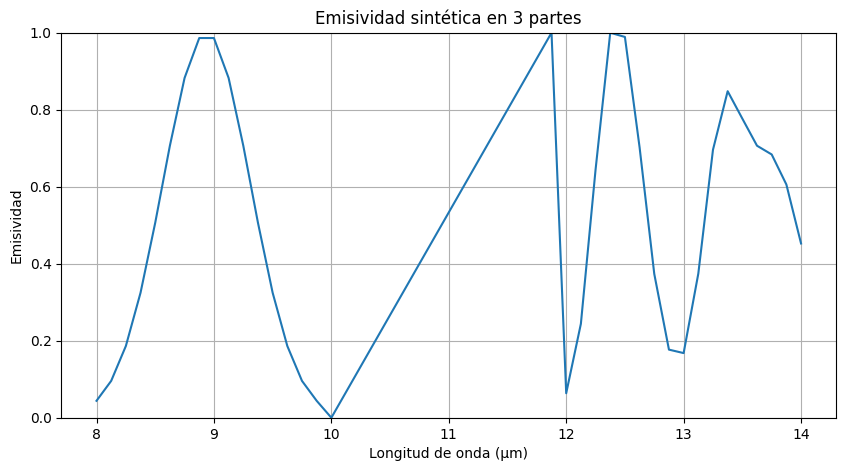

In [13]:
# Rejilla espectral (ajústala a tus bandas reales)
wl = np.linspace(8.0, 14.0, 49)

eps, parts = make_emissivity_3parts(
    wl,
    M_spikes=8,                 # más picos si quieres región bien “rica”
    sigma_gauss_part1=0.20,     # gaussiana algo más ancha en la 1a parte
    spike_amp_range=(0.3, 1.0), # amplitudes 0.3..1.0
    spike_sigma_range_frac=(0.03, 0.12), # picos de ancho corto a medio
    seed=1234
)

# (Opcional) Visualización rápida
# import matplotlib.pyplot as plt
# plt.plot(wl, eps, marker='o'); plt.xlabel('λ (µm)'); plt.ylabel('ε'); plt.ylim(0,1); plt.show()
plt.figure(figsize=(10, 5))
plt.plot(wl, eps)
plt.title("Emisividad sintética en 3 partes")
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Emisividad")
plt.ylim(0, 1)
plt.grid()
plt.show()

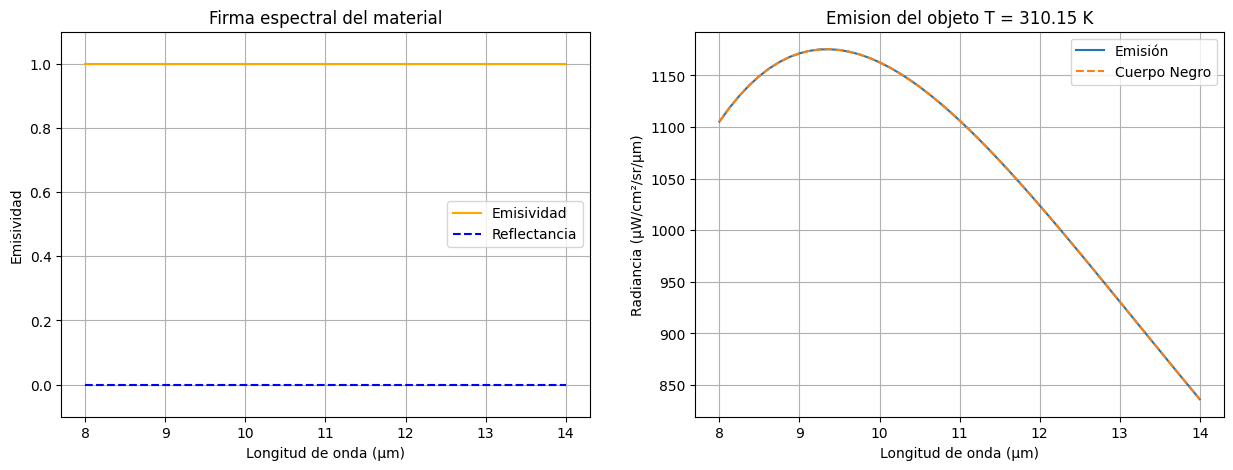

In [14]:
temperatura = 310.15  # temperatura objeto
temperatura_aire = 353.15

wave_lengths = np.linspace(8000, 14000, 49).astype(int)

black_body = blackbody_radiance_nm(wave_lengths, temperatura)  # radiancia del objeto
black_body_air = blackbody_radiance_nm(wave_lengths, temperatura_aire)  # radiancia del aire

firma = np.ones_like(wave_lengths, dtype=float)

emision = black_body * firma  # emision del objeto

reflectance = (1-firma)

# subplots
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(wave_lengths/1000, firma, label='Emisividad', color='orange')
plt.plot(wave_lengths/1000, reflectance, label='Reflectancia', color='blue', linestyle='--')
plt.title(f"Firma espectral del material")
plt.xlabel("Longitud de onda (μm)")
plt.ylabel("Emisividad")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(wave_lengths/1000, emision, label='Emisión')
plt.plot(wave_lengths/1000, black_body, linestyle='--', label='Cuerpo Negro')
plt.title(f"Emision del objeto T = {temperatura} K")
plt.xlabel("Longitud de onda (μm)")
plt.ylabel("Radiancia (μW/cm²/sr/μm)")
plt.grid()
plt.legend()

plt.show()


In [15]:
def lista_a_string(valores):
    return ", ".join(str(v) for v in valores)

In [16]:
dragon_emision = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

dragon_blackbody = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body),
        },
    },
}

dragon_air = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body_air),
        },
    },
}

dragon_emision_reflectance = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "bsdf": {
        "type": "diffuse",
        "reflectance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values":      lista_a_string(reflectance),
        },
    },
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

In [17]:
def get_attenuation_for_wavelengths(wavelengths: np.ndarray, attenuation_file: str = "air") -> np.ndarray:

        wavelengths_um = wavelengths / 1000.0

        try:
            # Construir la ruta del archivo
            file_path = f"../assets/reference_data/{attenuation_file}.txt"
            
            # Cargar los datos del archivo
            trans_array = np.loadtxt(file_path)
            
            # Extraer columnas: [wavelength, transmittance, attenuation]
            file_wavelengths = trans_array[:, 0]  # Primera columna: longitudes de onda
            file_attenuation = trans_array[:, 2]  # Tercera columna: atenuación
            
            # Encontrar los índices más cercanos para cada longitud de onda deseada
            attenuation_values = []
            
            for target_wavelength in wavelengths_um:
                # Encontrar el índice del valor más cercano
                closest_index = np.argmin(np.abs(file_wavelengths - target_wavelength))
                attenuation_values.append(file_attenuation[closest_index])

            original = np.array(attenuation_values)
            
            attenuation_array = np.array(attenuation_values)

            attenuation_array = attenuation_array * (np.log(10) / 10)
            
            return [attenuation_array, original]

        except (OSError, ValueError) as e:
            raise RuntimeError("Error al obtener la atenuación") from e


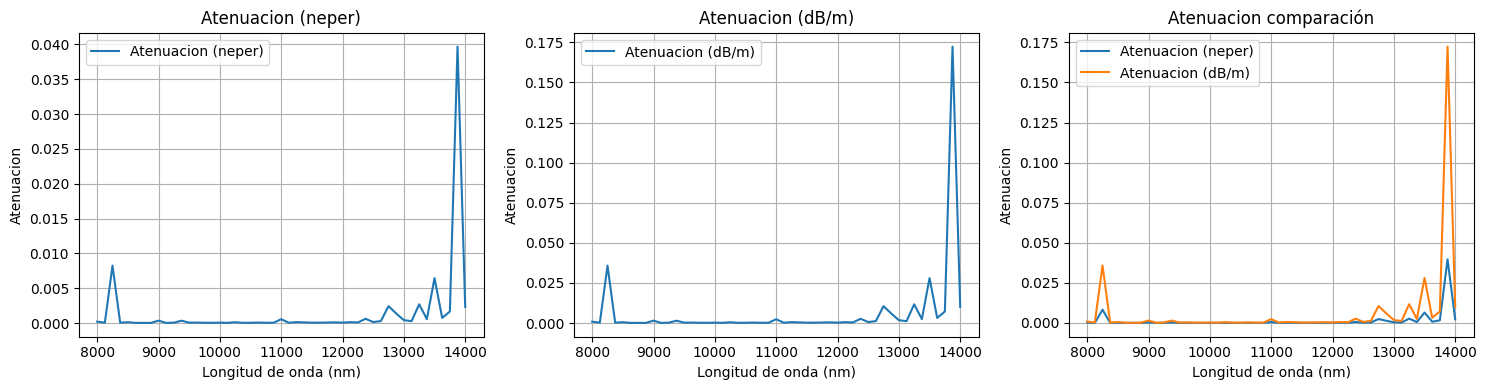

In [18]:
attenation_file = "air"
sigma_t, original_sigma_t = get_attenuation_for_wavelengths(wave_lengths, attenation_file)



# sigma_t[24] = 0
# sigma_t[25] = 0
# sigma_t[26] = 0
# sigma_t[27] = 1
# sigma_t[28] = 1
# sigma_t[29] = 1

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(wave_lengths, sigma_t, label="Atenuacion (neper)")
plt.title("Atenuacion (neper)")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Atenuacion")
plt.grid()
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(wave_lengths, original_sigma_t, label="Atenuacion (dB/m)")
plt.title("Atenuacion (dB/m)")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Atenuacion")
plt.grid()
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(wave_lengths, sigma_t, label="Atenuacion (neper)")
plt.plot(wave_lengths, original_sigma_t, label="Atenuacion (dB/m)")
plt.title("Atenuacion comparación")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Atenuacion")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

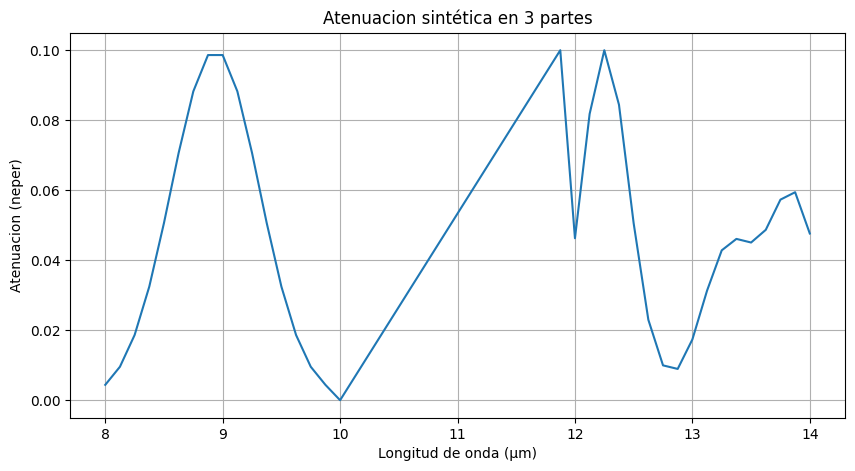

In [19]:
atenuacion, parts = make_emissivity_3parts(
    wl,
    M_spikes=8,                 # más picos si quieres región bien “rica”
    sigma_gauss_part1=0.20,     # gaussiana algo más ancha en la 1a parte
    spike_amp_range=(0.3, 1.0), # amplitudes 0.3..1.0
    spike_sigma_range_frac=(0.03, 0.12), # picos de ancho corto a medio
    seed=999999
)

atenuacion = atenuacion * 0.1

plt.figure(figsize=(10, 5))
plt.plot(wl, atenuacion)
plt.title("Atenuacion sintética en 3 partes")
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Atenuacion (neper)")
plt.grid()
plt.show()

sigma_t = atenuacion

In [20]:


niebla = {
    "type": "homogeneous",  # medio homogeneo, es decir el mismo sigma en todo el espacio,
    "id": "niebla",  # identificador del medio, para referenciarlo
    "albedo": {
        "type": "constvolume",  # textura volumétrica constante
        "value": {"type": "uniform", "value": 0.0},
    },
    "sigma_t": {
        "type": "constvolume",
        "value": {
            "type": "irregular",  # definimos un espectro
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(sigma_t),
        },
    },
    "phase": {  # define como se dispersa la luz en el medio (no la he entendido bien)
        "type": "hg",
        "g": 0.95,  # usar valores de 0.9-0.95 que es lo que pasa en el infrarrojo lejano, preguntarle al profe
        # con este nuevo valor pareciera que no existiera niebla, pero si lo pongo en 0.0 se ve la niebla
    },
}

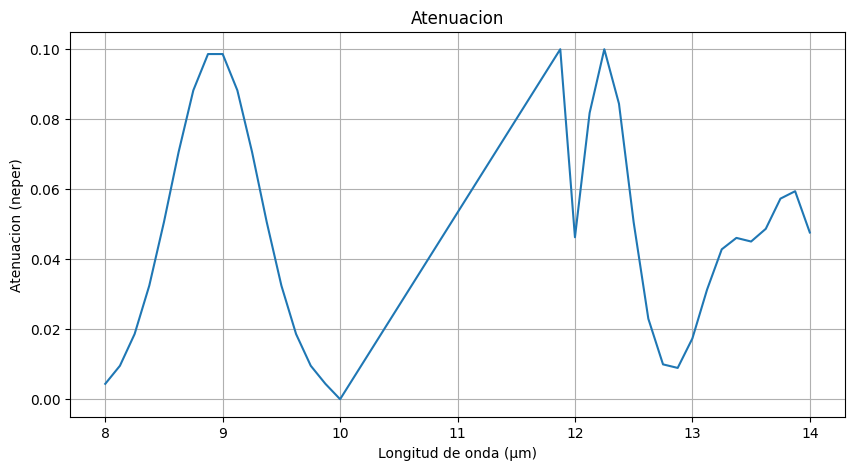

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(wave_lengths/1000, sigma_t)
plt.title("Atenuacion")
plt.xlabel('Longitud de onda (μm)')
plt.ylabel("Atenuacion (neper)")
plt.grid()
plt.show()

In [22]:
sensor_espectral_niebla = load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
sensor_espectral_niebla["medium"] = {"type": "ref", "id": "niebla"}

sensor_espectral_sin_niebla = load_sensor_spectral(
    r, phi, theta, wave_lengths, sigma, k, n
)

sensor_depth = load_sensor_depth(r, phi, theta)

In [23]:
integrador_niebla = {"type": "volpathmis", "max_depth": 8}

integrador_sin_niebla = {"type": "path"}

In [24]:
scene_sin_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_sin_niebla,
        "sensor": sensor_espectral_sin_niebla,
        "dragon": dragon_emision,
    }
)

scene_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon_emision,
    }
)
scene_depth = mi.load_dict(
    {
        "type": "scene",
        "integrator": {
            "type": "depth",
        },
        "sensor": sensor_depth,
        "dragon": dragon_emision,
    }
)

# scene_sin_niebla_reflectance = mi.load_dict(
#     {
#         "type": "scene",
#         "integrator": integrador_sin_niebla,
#         "sensor": sensor_espectral_sin_niebla,
#         "dragon": dragon_emision_reflectance,
#         "emitter": {
#             "type": "constant",
#             "radiance": {
#                 "type": "irregular",
#                 "wavelengths": lista_a_string(wave_lengths),
#                 "values": lista_a_string(black_body_air),
#             },
#         },
#     }
# )

# scene_niebla_reflectance = mi.load_dict(
#     {
#         "type": "scene",
#         "integrator": integrador_niebla,
#         "niebla": niebla,
#         "sensor": sensor_espectral_niebla,
#         "dragon": dragon_emision_reflectance,
#         "emitter": {
#             "type": "constant",
#             "radiance": {
#                 "type": "irregular",
#                 "wavelengths": lista_a_string(wave_lengths),
#                 "values": lista_a_string(black_body_air),
#             },
#         },
#     }
# )

In [25]:
#imagen_niebla = mi.render(scene_niebla, spp=spp)
#imagen_sin_niebla = mi.render(scene_sin_niebla, spp=spp)
#imagen_depth = mi.render(scene_depth, spp=spp)
#imagen_niebla_reflectance = mi.render(scene_niebla_reflectance, spp=spp)
#imagen_sin_niebla_reflectance = mi.render(scene_sin_niebla_reflectance, spp=spp)

In [26]:
def RMSE (array1, array2):
    return np.sqrt(np.mean((array1 - array2) ** 2))

def NRMSE (array1, array2):
    return RMSE(array1, array2) / (np.max(array2) - np.min(array2))

In [27]:
wave_lengths = np.linspace(8000, 14000, 49).astype(int)

spp = 1024 * 16 
x = 200
y = 150

In [28]:
rs = [5, 20, 100] 

In [29]:
imagenes = []
imagenes_sin_niebla = []
scenes = []
scenes_sin_niebla = []
scenes_depth = []
depths = []
T_teoricos = []
T_renderizados = []

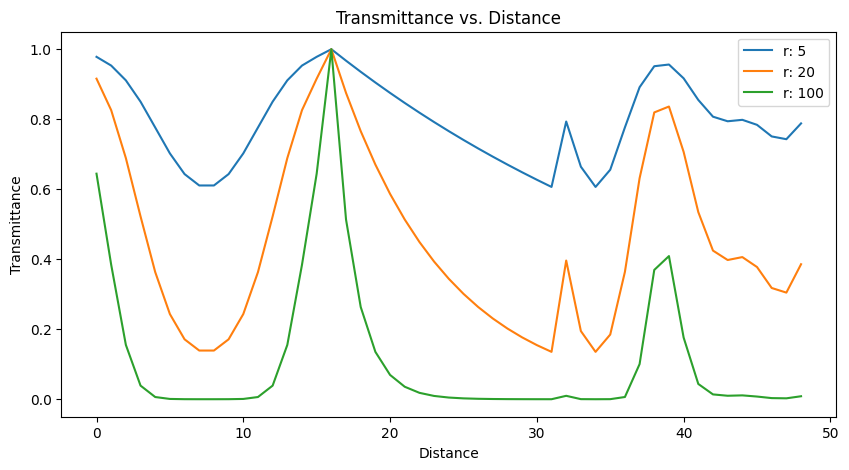

In [30]:
plt.figure(figsize=(10, 5))

for r in rs:
    values = np.exp(-sigma_t * r)
    max_value = np.max(values)
    min_value = np.min(values)

    plt.plot(values, label=f"r: {r}")

    
plt.title("Transmittance vs. Distance")
plt.xlabel("Distance")
plt.ylabel("Transmittance")
plt.legend()
plt.show()



In [31]:
for r in rs:

    dragon = {
        "type": "obj",
        "filename": "Dragon.obj",
        "to_world": T().translate([0, 0, 0]),
        "emitter": {
            "type": "area",
            "radiance": {
                "type": "irregular",
                "wavelengths": lista_a_string(wave_lengths),
                "values": lista_a_string(emision),
            },
        },
    }

    niebla = {
        "type": "homogeneous", 
        "id": "niebla", 
        "albedo": {
            "type": "constvolume", 
            "value": {"type": "uniform", "value": 0.0},
        },
        "sigma_t": {
            "type": "constvolume",
            "value": {
                "type": "irregular",
                "wavelengths": lista_a_string(wave_lengths),
                "values": lista_a_string(sigma_t),
            },
        },
        "phase": {
            "type": "hg",
            "g": 0.95, 
        },
    }

    sensor = load_sensor_spectral(
        r, phi, theta, wave_lengths, sigma, k, n
    )

    sensor["medium"] = {"type": "ref", "id": "niebla"}

    sensor_sin_niebla = load_sensor_spectral(
        r, phi, theta, wave_lengths, sigma, k, n
    )

    sensor_depth = load_sensor_depth(r, phi, theta)

    integrador = {"type": "volpathmis", "max_depth": 16}

    integrador_sin_niebla = {"type": "path"}

    integrador_depth = {"type": "depth"}

    scene = mi.load_dict(
        {
            "type": "scene",
            "integrator": integrador,
            "niebla": niebla,
            "sensor": sensor,
            "dragon": dragon,
        }
    )

    scene_sin_niebla = mi.load_dict(
        {
            "type": "scene",
            "integrator": integrador_sin_niebla,
            "sensor": sensor_sin_niebla,
            "dragon": dragon,
        }
    )

    scene_depth = mi.load_dict(
        {
            "type": "scene",
            "integrator": integrador_depth,
            "sensor": sensor_depth,
            "dragon": dragon,
        }
    )

    scenes.append(scene)
    scenes_depth.append(scene_depth)
    scenes_sin_niebla.append(scene_sin_niebla)




In [41]:
ys = [100,150,150]
xs = [100,175,140]

In [33]:
for i, scene in enumerate(scenes):
    imagen = mi.render(scene, spp=spp)
    imagen_sin_niebla = mi.render(scenes_sin_niebla[i], spp=spp)
    imagen_depth = mi.render(scenes_depth[i], spp=spp)
    
    imagenes.append(imagen)
    depths.append(imagen_depth)
    imagenes_sin_niebla.append(imagen_sin_niebla)


In [44]:
T_teoricos = []
T_renderizados = []

for i, depth in enumerate(depths):
    T_teorica = np.exp(-sigma_t * depth[ys[i],xs[i]])
    T_renderizada = imagenes[i][ys[i],xs[i],:]/imagenes_sin_niebla[i][ys[i],xs[i],:]

    T_teoricos.append(T_teorica)
    T_renderizados.append(T_renderizada)

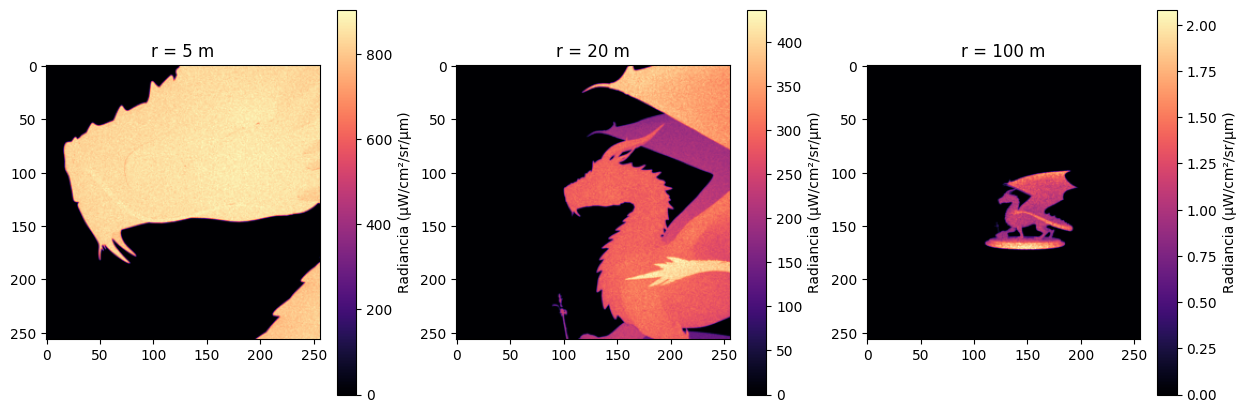

In [45]:
plt.figure(figsize=(15, 5))

for i, r in enumerate(rs):
    plt.subplot(1,3, i+1)
    plt.imshow(imagenes[i][:, :, 5], cmap='magma')
    plt.colorbar(label='Radiancia (μW/cm²/sr/μm)')
    plt.title(f"r = {r} m")

plt.show()


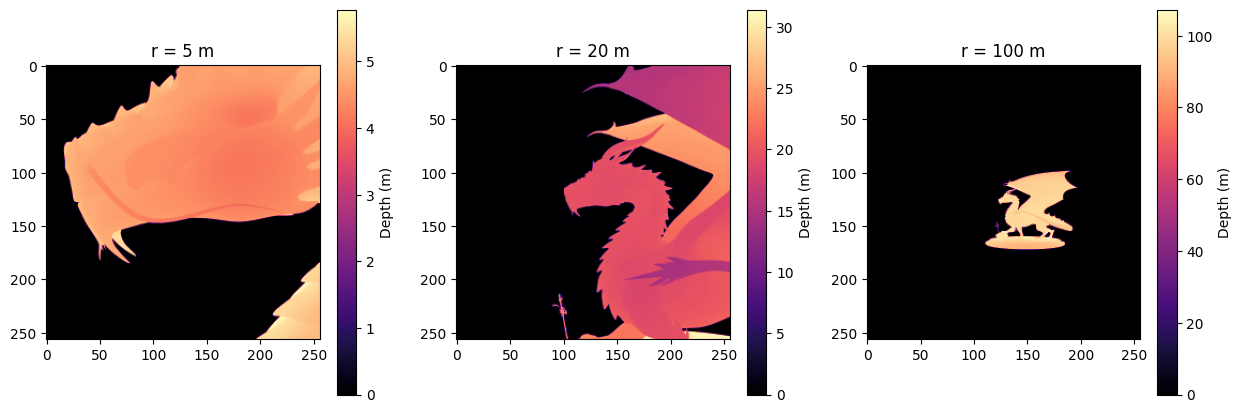

In [46]:
plt.figure(figsize=(15, 5))

for i, r in enumerate(rs):
    plt.subplot(1,3, i+1)
    plt.imshow(depths[i], cmap='magma')
    plt.colorbar(label='Depth (m)')
    plt.title(f"r = {r} m")

plt.show()

C:\Users\mgefr\AppData\Local\Temp\ipykernel_19952\1443532447.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d = float(np.asarray(depths[i])[ys[i], xs[i]])
C:\Users\mgefr\AppData\Local\Temp\ipykernel_19952\1443532447.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d = float(np.asarray(depths[i])[ys[i], xs[i]])


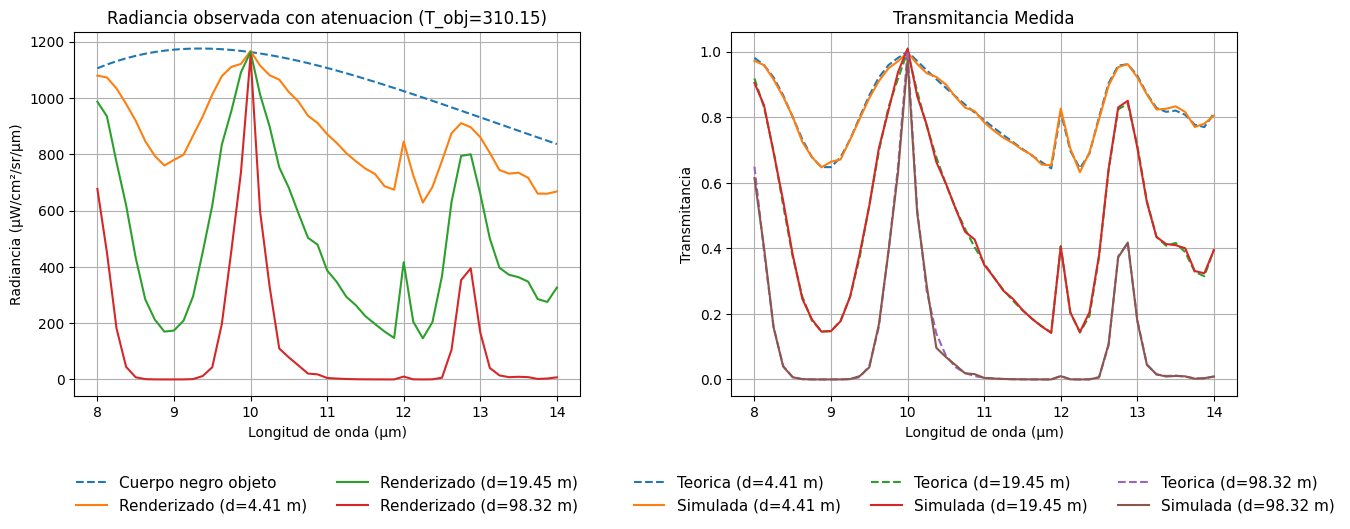

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Subplot 1
ax = axes[0]
ax.plot(wave_lengths/1000, black_body, linestyle='--', label='Cuerpo negro objeto')
for i, imagen in enumerate(imagenes):
    d = float(np.asarray(depths[i])[ys[i], xs[i]])
    ax.plot(wave_lengths/1000, imagen[ys[i], xs[i], :], label=f'Renderizado (d={d:.2f} m)')
ax.set_title('Radiancia observada con atenuacion (T_obj={:.2f})'.format(temperatura))
ax.set_xlabel('Longitud de onda (μm)')
ax.set_ylabel("Radiancia (μW/cm²/sr/μm)")
ax.grid(True)

# Subplot 2
ax2 = axes[1]
for i, T_teorica in enumerate(T_teoricos):
    d = float(np.asarray(depths[i])[ys[i], xs[i]])
    ax2.plot(wave_lengths/1000, T_teorica, linestyle='--', label=f'Teorica (d={d:.2f} m)')
    ax2.plot(wave_lengths/1000, T_renderizados[i], label=f'Simulada (d={d:.2f} m)')
ax2.set_title('Transmitancia Medida')
ax2.set_xlabel('Longitud de onda (μm)')
ax2.set_ylabel("Transmitancia")
ax2.grid(True)

# Leyendas fuera del área de las gráficas (aumentar fuente)
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1, labels1, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=11, frameon=False)
ax2.legend(handles2, labels2, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=11, frameon=False)

plt.subplots_adjust(bottom=0.36, wspace=0.3)
plt.show()